### Import necessary libraries for data processing, visualization, machine learning, and model evaluation
#### This cell loads all required Python libraries including pandas, matplotlib, scikit-learn, SHAP, and XGBoost.


In [1]:
import boto3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import shap
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [2]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


###  Load dataset from S3 into a Pandas DataFrame
Use the boto3 client to read the CSV file from S3 and load it into a DataFrame for analysis.


In [3]:
bucket_name = 'midterm-project-01'
file_key = 'sample_df_aws.csv'

# Create an S3 client
s3 = boto3.client('s3')

# Generate a presigned URL or use S3 object directly
obj = s3.get_object(Bucket=bucket_name, Key=file_key)

# Read the CSV data into a Pandas DataFrame
df = pd.read_csv(obj['Body'])

# Show the first few rows
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,file_year,file_month,airport_fee,PU_Borough,PU_Zone,DO_Borough,DO_Zone,Pickup_Point,Dropoff_Point,season
0,2,2022-11-02 14:15:20,2022-11-02 15:03:41,1.0,11.37,1.0,N,70,230,1,...,2022,11,1.25,Queens,East Elmhurst,Manhattan,Times Sq/Theatre District,"Queens, East Elmhurst","Manhattan, Times Sq/Theatre District",Fall
1,2,2022-10-15 13:02:51,2022-10-15 13:21:32,1.0,2.91,1.0,N,75,161,1,...,2022,10,0.00,Manhattan,East Harlem South,Manhattan,Midtown Center,"Manhattan, East Harlem South","Manhattan, Midtown Center",Fall
2,2,2022-02-04 12:46:20,2022-02-04 12:52:00,1.0,0.88,1.0,N,238,151,1,...,2022,2,0.00,Manhattan,Upper West Side North,Manhattan,Manhattan Valley,"Manhattan, Upper West Side North","Manhattan, Manhattan Valley",Winter
3,2,2022-08-31 23:39:25,2022-08-31 23:44:15,1.0,1.44,1.0,N,140,262,1,...,2022,8,0.00,Manhattan,Lenox Hill East,Manhattan,Yorkville East,"Manhattan, Lenox Hill East","Manhattan, Yorkville East",Summer
4,1,2022-01-25 13:29:29,2022-01-25 13:41:53,1.0,1.70,1.0,N,142,140,1,...,2022,1,0.00,Manhattan,Lincoln Square East,Manhattan,Lenox Hill East,"Manhattan, Lincoln Square East","Manhattan, Lenox Hill East",Winter


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1199988 entries, 0 to 1199987
Data columns (total 35 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   VendorID               1199988 non-null  int64  
 1   tpep_pickup_datetime   1199988 non-null  object 
 2   tpep_dropoff_datetime  1199988 non-null  object 
 3   passenger_count        1199988 non-null  float64
 4   trip_distance          1199988 non-null  float64
 5   RatecodeID             1199988 non-null  float64
 6   store_and_fwd_flag     1199988 non-null  object 
 7   PULocationID           1199988 non-null  int64  
 8   DOLocationID           1199988 non-null  int64  
 9   payment_type           1199988 non-null  int64  
 10  fare_amount            1199988 non-null  float64
 11  extra                  1199988 non-null  float64
 12  mta_tax                1199988 non-null  float64
 13  tip_amount             1199988 non-null  float64
 14  tolls_amount      

In [5]:
df.shape

(1199988, 35)

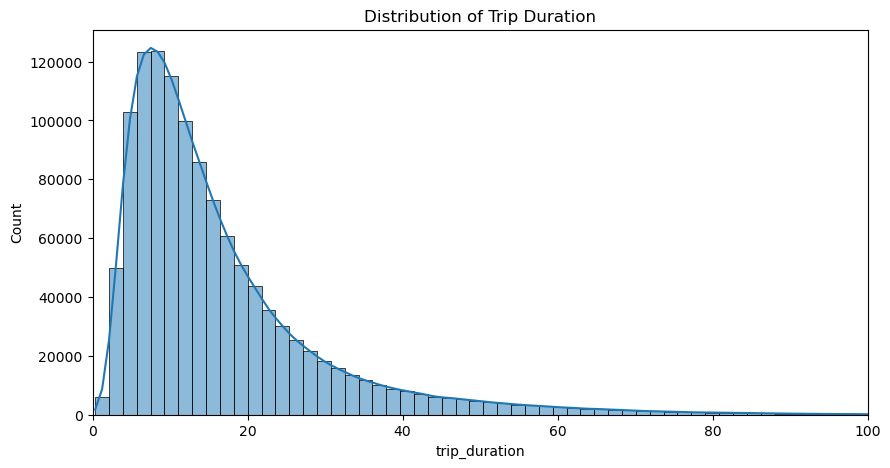

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df['trip_duration'], bins=100, kde=True)
plt.title('Distribution of Trip Duration')
plt.xlim(0, 100)
plt.show()

/tmp/ipykernel_8982/1418641264.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df.corr()


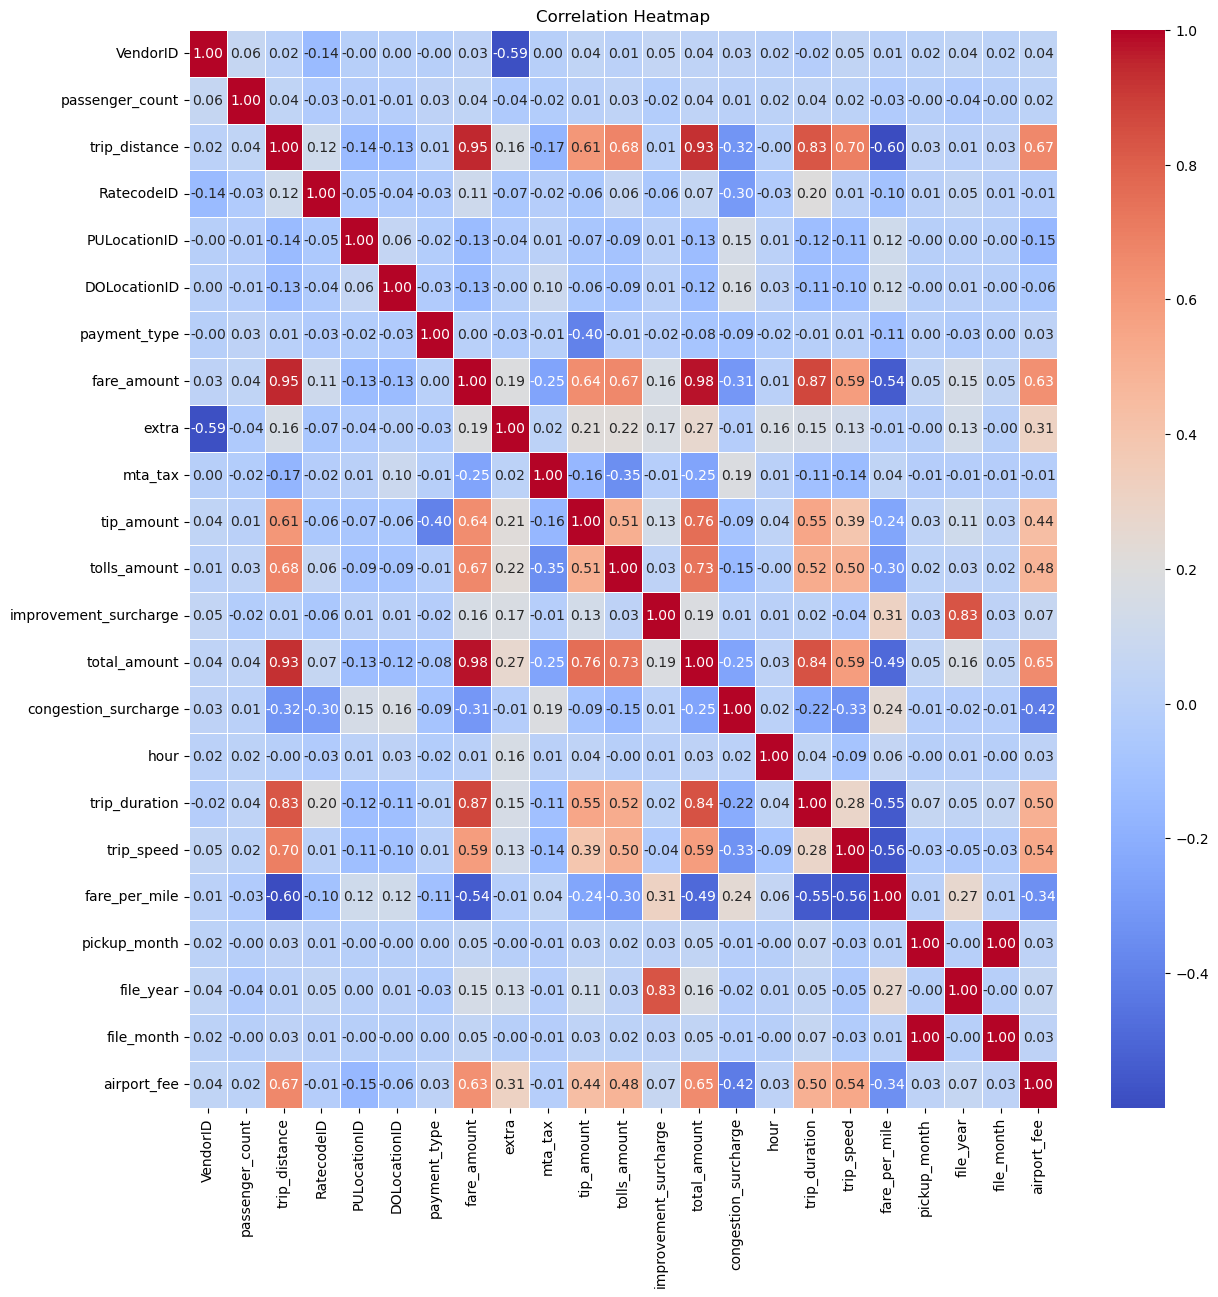

In [7]:
plt.figure(figsize=(14, 14))

correlation_matrix = df.corr() 

# Generate a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Display the plot
plt.title('Correlation Heatmap')
plt.show()

#### 1) fare_amount, mta_tax, tip_amount, tolls_amount,improvement_surcharge, congestion_surcharge, airport_fee, extra --> 
##### These columns are literally components of total_amount (they sum to it). Including them will give you an almost perfect fit—but it isn’t real forecasting; it’s just arithmetic. Our goal is genuinely to predict from trip characteristics, so we omit those breakdown columns.

#### 2)Highly Collinear columns
##### trip_distance, trip_duration, and derived trip_speed are tightly linked.


In [8]:
# Select features for modeling
features = [
    'trip_distance', 
    'passenger_count', 
    #'trip_duration', 
    # 'trip_speed', 
    'fare_per_mile',
    'hour', 
    'pickup_day', 
    'pickup_month', 
    'RatecodeID', 
    'payment_type',
    'mta_tax', 
    'tip_amount', 
    'tolls_amount', 
    'improvement_surcharge', 
    'congestion_surcharge', 
    'airport_fee',
    'VendorID' , 
    'PULocationID', 
    'DOLocationID', 
    'extra', 
    'fare_amount', 
    'time_slot', 
    'season',
    'total_amount'
]
target = 'trip_duration'

In [9]:
# Subset the DataFrame
selected_columns = features + [target]
new_df = df[selected_columns].copy()

# Quick check
print(new_df.shape)
new_df.head()


(1199988, 23)


,trip_distance,passenger_count,fare_per_mile,hour,pickup_day,pickup_month,RatecodeID,payment_type,mta_tax,tip_amount,...,airport_fee,VendorID,PULocationID,DOLocationID,extra,fare_amount,time_slot,season,total_amount,trip_duration
0,11.37,1.0,5.445910,15,Wednesday,11,1.0,1,0.5,10.32,...,1.25,2,70,230,0.0,40.5,Afternoon,Fall,61.92,48.350000
1,2.91,1.0,7.134021,13,Saturday,10,1.0,1,0.5,3.46,...,0.00,2,75,161,0.0,14.0,Afternoon,Fall,20.76,18.683333
2,0.88,1.0,13.409091,12,Friday,2,1.0,1,0.5,3.00,...,0.00,2,238,151,0.0,5.5,Afternoon,Winter,11.80,5.666667
3,1.44,1.0,7.638889,23,Wednesday,8,1.0,1,0.5,1.20,...,0.00,2,140,262,0.5,6.0,Night,Summer,11.00,4.833333
4,1.70,1.0,9.764706,13,Tuesday,1,1.0,1,0.5,3.30,...,0.00,1,142,140,2.5,10.0,Afternoon,Winter,16.60,12.400000


#### Encoding


##### One-Hot Encoding

In [10]:
def one_hot_encode(df: pd.DataFrame, column: str, drop_first: bool = False) -> pd.DataFrame:
    """
    One-hot encode the specified column in-place (or can assign the result to a new DataFrame).

    Parameters:
    - df: DataFrame containing the column to encode.
    - column: Name of the categorical column to one-hot encode.
    - drop_first: If True, drops the first level to avoid multicollinearity (useful for linear models).

    Returns:
    - A new DataFrame with the original column replaced by its one-hot encoded dummy columns.
    """
    return pd.get_dummies(
        df,
        columns=[column],
        prefix=column,
        drop_first=drop_first,
        dtype=int
    )

In [11]:
df_encoded = one_hot_encode(new_df, 'season', drop_first=True)

### Define a function to apply cyclical encoding to periodic features
Create a reusable function to encode features like hour, day, or month into sine and cosine components for machine learning models.


In [12]:
def cyclical_encode(df, column, period, prefix=None, drop_original=False):
    """
    Applies cyclical encoding to a numeric column.
    
    Parameters:
    - df: pandas DataFrame containing the column.
    - column: str, name of the column to encode (values 0..period-1).
    - period: int, the cycle length (e.g., 24 for hours, 7 for days, 12 for months).
    - prefix: str or None, base for new column names; defaults to column name.
    - drop_original: bool, if True, drops the original column after encoding.
    
    Returns:
    - df: DataFrame with two new columns: <prefix>_sin and <prefix>_cos.
    """    
    name = prefix if prefix else column
    values = df[column].astype(float)
    
    df[f"{name}_sin"] = np.sin(2 * np.pi * values / period)
    df[f"{name}_cos"] = np.cos(2 * np.pi * values / period)
    
    if drop_original:
        df.drop(columns=[column], inplace=True)
    
    return df

In [13]:
df_encoded = cyclical_encode(df_encoded, 'hour', period=24, prefix='hour', drop_original=False)

day_map = {
    'Monday':    0,
    'Tuesday':   1,
    'Wednesday': 2,
    'Thursday':  3,
    'Friday':    4,
    'Saturday':  5,
    'Sunday':    6
}
df_encoded['pickup_day_idx'] = df['pickup_day'].map(day_map)

# 2) now apply cyclical encoder
df_encoded = cyclical_encode( df_encoded, column='pickup_day_idx', period=7, prefix='pickup_day', drop_original=True )

In [14]:
# Drop every column as well
df_encoded.drop(columns='hour', inplace=True)

df_encoded.drop(columns='pickup_day', inplace=True)

In [15]:
df_encoded = cyclical_encode( df_encoded, column='pickup_month',  period=12,  prefix='pickup_month',  drop_original=True)

df_encoded = one_hot_encode(df_encoded, column='time_slot', drop_first=True)


In [16]:
df_encoded.columns

Index(['trip_distance', 'passenger_count', 'fare_per_mile', 'RatecodeID',
       'payment_type', 'mta_tax', 'tip_amount', 'tolls_amount',
       'improvement_surcharge', 'congestion_surcharge', 'airport_fee',
       'VendorID', 'PULocationID', 'DOLocationID', 'extra', 'fare_amount',
       'total_amount', 'trip_duration', 'season_Spring', 'season_Summer',
       'season_Winter', 'hour_sin', 'hour_cos', 'pickup_day_sin',
       'pickup_day_cos', 'pickup_month_sin', 'pickup_month_cos',
       'time_slot_Evening', 'time_slot_Morning', 'time_slot_Night'],
      dtype='object')

In [17]:
continuous_cols = [
    'trip_distance',
    'passenger_count',
    'total_amount',
    'fare_per_mile',
    'mta_tax', 
    'tip_amount', 
    'tolls_amount', 
    'improvement_surcharge', 
    'congestion_surcharge', 
    'airport_fee',
    'extra', 
    'fare_amount'
]

In [18]:
# Initialize the scaler
scaler = StandardScaler()

# Fit on those columns and transform in place
df_encoded[continuous_cols] = scaler.fit_transform(df_encoded[continuous_cols])

In [19]:
df_encoded.columns

Index(['trip_distance', 'passenger_count', 'fare_per_mile', 'RatecodeID',
       'payment_type', 'mta_tax', 'tip_amount', 'tolls_amount',
       'improvement_surcharge', 'congestion_surcharge', 'airport_fee',
       'VendorID', 'PULocationID', 'DOLocationID', 'extra', 'fare_amount',
       'total_amount', 'trip_duration', 'season_Spring', 'season_Summer',
       'season_Winter', 'hour_sin', 'hour_cos', 'pickup_day_sin',
       'pickup_day_cos', 'pickup_month_sin', 'pickup_month_cos',
       'time_slot_Evening', 'time_slot_Morning', 'time_slot_Night'],
      dtype='object')

### Split the dataset into training and testing sets
Separate features and target variable, then split the data into 80% training and 20% testing to prepare for model training and evaluation.


In [20]:
# 1. Separate features and target

X = df_encoded.drop(columns=['trip_duration'])
y = df_encoded['trip_duration']

# 2. Split into train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 20% hold-out for testing
    random_state=42      # for reproducibility
)

# Quick sanity check

print("X_train:", X_train.shape)
print("X_test:",  X_test.shape)
print("y_train:", y_train.shape)
print("y_test:",  y_test.shape)

X_train: (959990, 29)
X_test: (239998, 29)
y_train: (959990,)
y_test: (239998,)


### Train a Linear Regression model and evaluate its performance
Fit a Linear Regression model on the training data, make predictions, and compute evaluation metrics (R², MSE, MAE) on the test set.


In [21]:
# 1. Instantiate and train the model
lr = LinearRegression()
lr.fit(X_train, y_train)

# 2. Predict on the test set
y_pred = lr.predict(X_test)

# 3. Compute metrics
r2  = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

# 4. Print results
print(f"R²:  {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

R²:  0.8308
MSE: 29.7435
MAE: 3.1374


#### Predicting trip_duration with an R² of 0.8308 means our linear model is capturing about 783 % of the variability in trip times
#### MAE ≈ 3.13 - On average we’re off by about 3 “units” (e.g. minutes) per trip.
#### RMSE ≈ √29.74 ≈ 5.45 - Larger errors (outliers) are dragging the root‐mean‐squared error up to roughly 5.45 minutes.

In [22]:
# 2. Initialize model
model = LinearRegression()

# 3. Define the scoring metrics
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error',
    'R2': 'r2'
}

# 4. Run 5-fold cross-validation
cv_results = cross_validate(
    model,
    X,
    y,
    scoring=scoring,
    cv=5,
    return_train_score=False
)

# 2) Fold‐wise summary in a DataFrame
cv_df = pd.DataFrame({
    'MAE':  -cv_results['test_MAE'],
    'MSE':  -cv_results['test_MSE'],
    'RMSE': np.sqrt(-cv_results['test_MSE']),
    'R2':   cv_results['test_R2']
})

cv_df.index = [f"Fold {i+1}" for i in cv_df.index]
print("\nFold-wise performance:")
print(cv_df)


Fold-wise performance:
             MAE        MSE      RMSE        R2
Fold 1  3.661698  34.744907  5.894481  0.774957
Fold 2  3.319233  30.876104  5.556627  0.808710
Fold 3  2.994176  28.351455  5.324608  0.837422
Fold 4  3.072057  30.995089  5.567323  0.837109
Fold 5  3.112610  32.874785  5.733654  0.836563


#### The fold-wise results show consistent performance across all folds, with R² scores ranging from 0.77 to 0.84 and RMSE values around 5.3 to 5.9, indicating that the model generalizes well with stable and reliable predictions across different data splits.

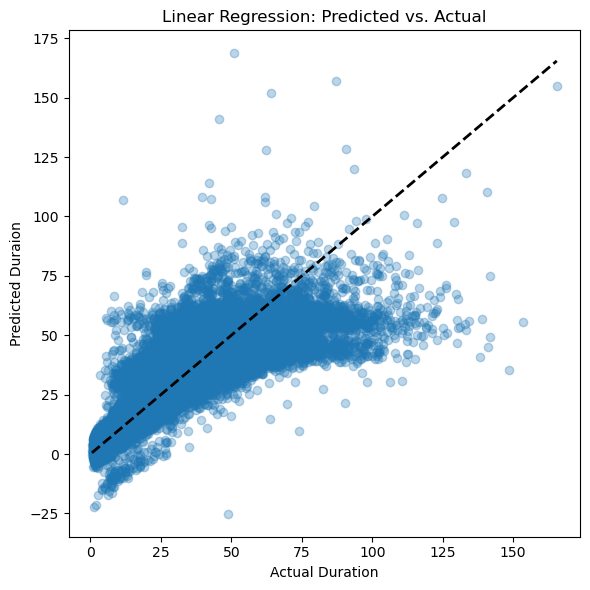

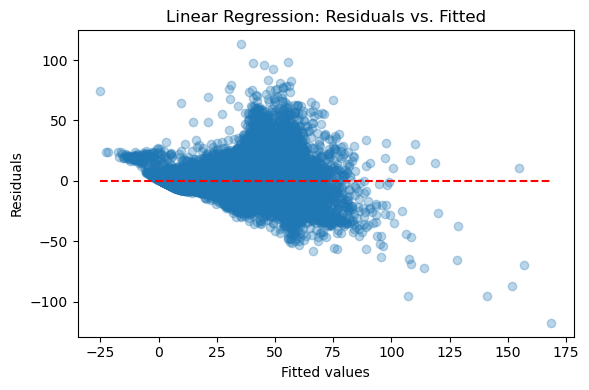

In [23]:
_pred_lr    = lr.predict(X_test)
residuals_lr = y_test - y_pred

# 2. Predicted vs. Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--', linewidth=2
)
plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duraion")
plt.title("Linear Regression: Predicted vs. Actual")
plt.tight_layout()
plt.show()

# 3. Residuals vs. Fitted
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals_lr, alpha=0.3)
plt.hlines(
    0,
    y_pred.min(),
    y_pred.max(),
    colors='r',
    linestyles='dashed'
)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Linear Regression: Residuals vs. Fitted")
plt.tight_layout()
plt.show()

#### The residual plot for Linear Regression shows a fanning pattern, indicating heteroscedasticity, where prediction errors increase as the fitted fare values grow, suggesting that the model struggles to maintain consistent accuracy across higher fare amounts.

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


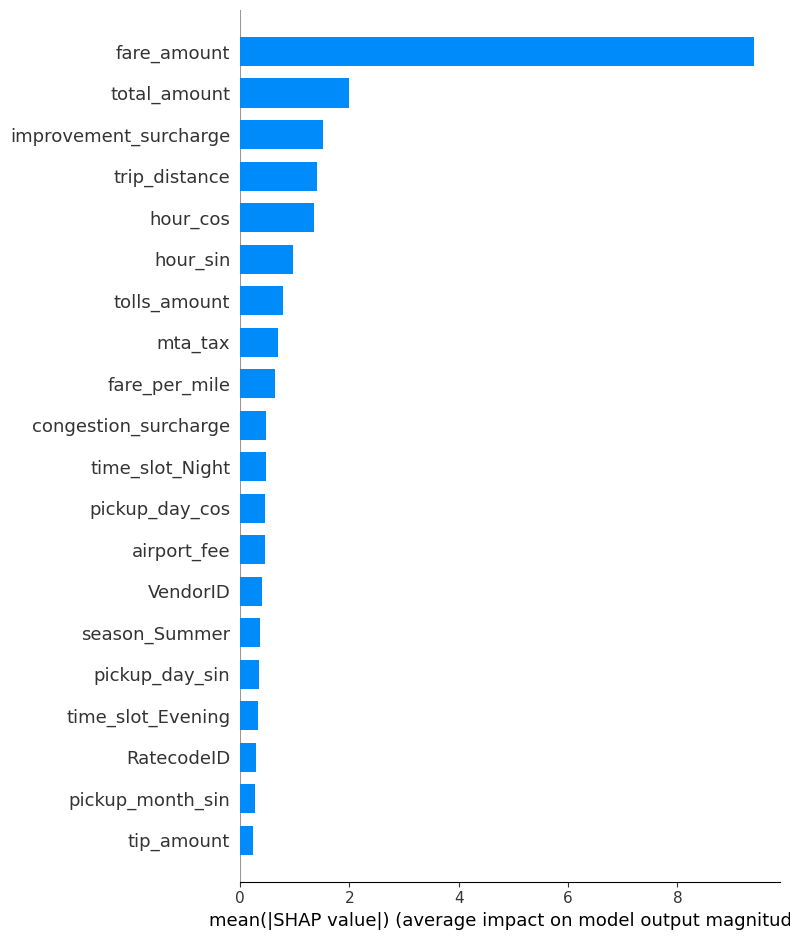

In [29]:
# 1. Create a SHAP explainer for a linear model
explainer = shap.LinearExplainer(
    lr,                    # trained LinearRegression
    X_train,               # background dataset
    feature_perturbation="interventional"  # recommended for linear models
)

# 2. Calculate SHAP values on the test set
shap_values = explainer.shap_values(X_test)

# 3. Summary plot (global feature importance)
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type="bar",       # bar chart of mean(|SHAP|)
    feature_names=X_test.columns
)

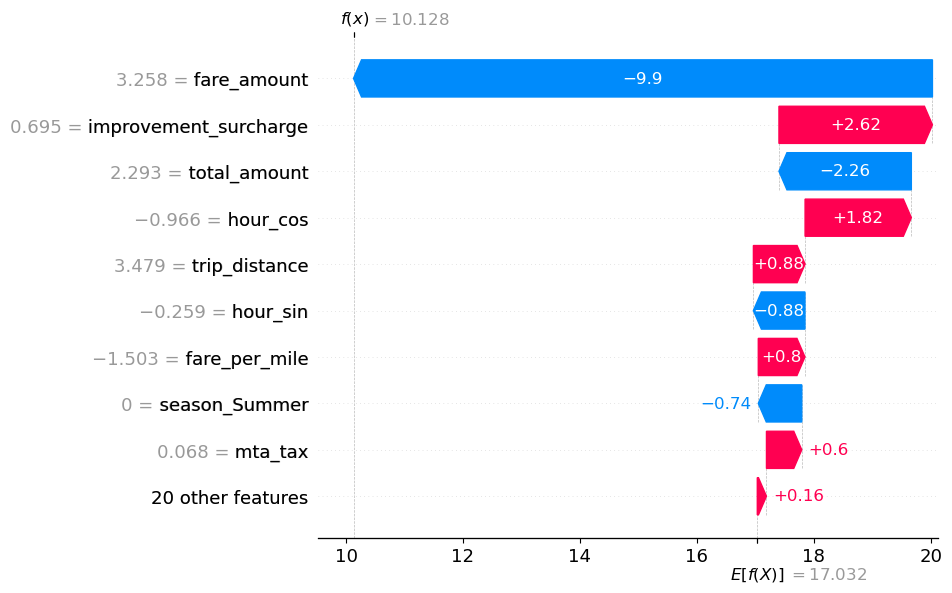

In [30]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[2],
        base_values=explainer.expected_value,
        data=X_test.iloc[1],
        feature_names=X_test.columns
    )
)

### Net effect: Starting at 17.467, the model subtracts ~9.3 min for cost/distance cues, then adds back ~4.2 min for time‐of‐day and other small factors, landing at 10.962 min.


### Instantiate a Random Forest Regressor with initial hyperparameters
Create a Random Forest model with controlled complexity and subsampling to balance accuracy and computational efficiency.


In [24]:
# 1. Instantiate a lighter, more resource-friendly forest
rf = RandomForestRegressor(
    n_estimators=50,         # trees
    max_depth=20,            # cap tree depth
    max_features='sqrt',     # use √(n_features) at each split
    min_samples_leaf=5,      # require at least 5 samples at each leaf
    max_samples=0.5,         # sample 50% of rows per tree (sklearn ≥1.2)
    random_state=42,
    n_jobs=-1,               # use all cores, but with smaller trees
    verbose=1                # show progress
)

In [25]:
# 2. Fit on the training data
rf.fit(X_train, y_train)

# 3. Predict on the test set
y_pred_rf = rf.predict(X_test)

# 4. Evaluate performance
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"MAE:  {mae_rf:.4f}")
print(f"MSE:  {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²:   {r2_rf:.4f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   47.6s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:   51.5s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.5s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    2.7s finished


Random Forest Performance:
MAE:  1.5198
MSE:  11.5119
RMSE: 3.3929
R²:   0.9345


#### The Random Forest model achieved strong performance with an R² of 0.9345 and a low RMSE of 3.39, indicating high predictive accuracy and small average errors in fare prediction.

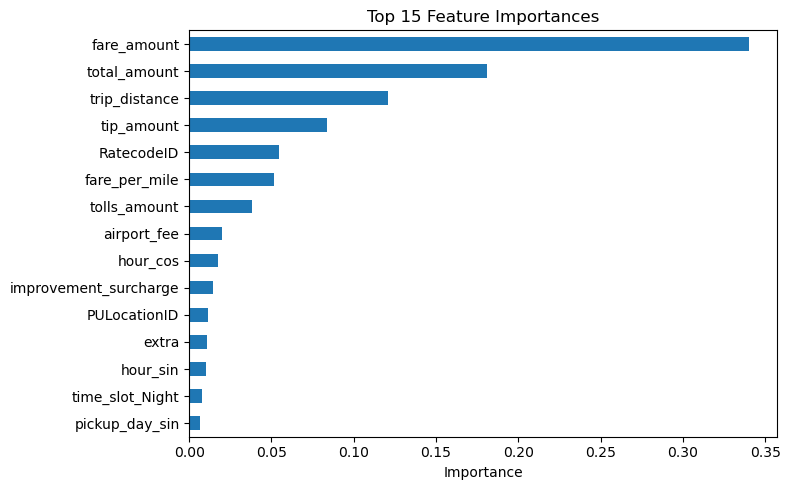

In [33]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)[:15]  # top 15

plt.figure(figsize=(8,5))
importances.plot.barh()
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.6s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    2.8s finished


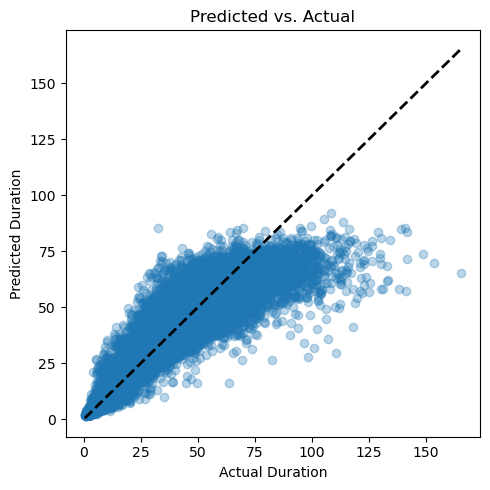

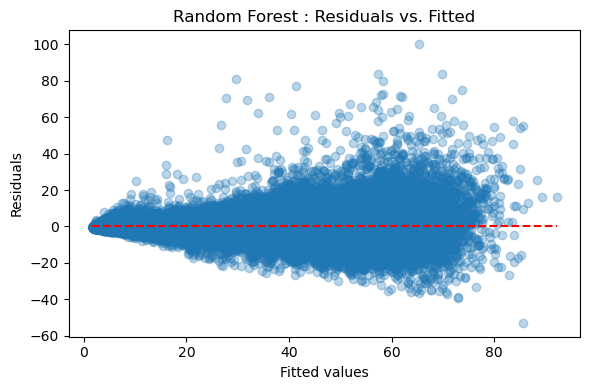

In [34]:
y_pred = rf.predict(X_test)

# 1) Pred vs. actual
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', lw=2)
plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.title("Predicted vs. Actual")
plt.tight_layout()

# 2) Residuals vs. fitted
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.hlines(0, y_pred.min(), y_pred.max(), colors='r', linestyles='dashed')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Random Forest : Residuals vs. Fitted")
plt.tight_layout()


#### Residuals are now more evenly scattered around zero with a fairly constant spread across fitted values, indicating the Random Forest has largely tamed the heteroscedasticity seen in the linear model.

### XGBoost

In [26]:
xgb_base = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# fit with an early-stopping callback
xgb_base.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    # eval_metric='rmse',
    # early_stopping_rounds=10,
    verbose=10
)

[0]	validation_0-rmse:12.17506	validation_1-rmse:12.13314
[10]	validation_0-rmse:6.04229	validation_1-rmse:6.01158
[20]	validation_0-rmse:4.40024	validation_1-rmse:4.38787
[30]	validation_0-rmse:3.91483	validation_1-rmse:3.91999
[40]	validation_0-rmse:3.68052	validation_1-rmse:3.69889
[50]	validation_0-rmse:3.53909	validation_1-rmse:3.56948
[60]	validation_0-rmse:3.43235	validation_1-rmse:3.47289
[70]	validation_0-rmse:3.36807	validation_1-rmse:3.41832
[80]	validation_0-rmse:3.30385	validation_1-rmse:3.36558
[90]	validation_0-rmse:3.24728	validation_1-rmse:3.32019
[99]	validation_0-rmse:3.20248	validation_1-rmse:3.28223


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

In [27]:
y_pred = xgb_base.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"XGB R²: {r2:.4f}")

XGB R²: 0.9387


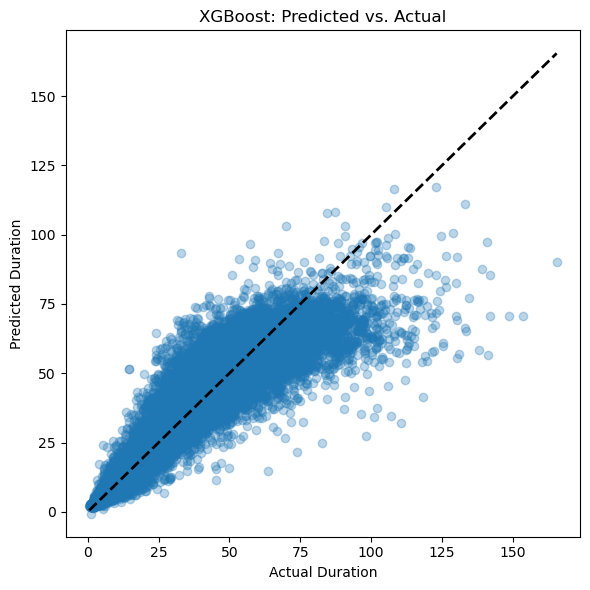

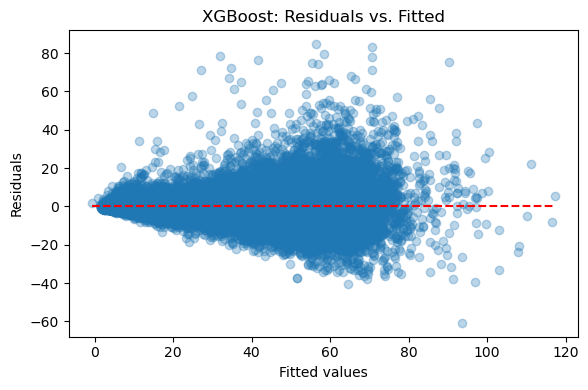

In [38]:
# 1. Get predictions
y_pred_xgb = xgb_base.predict(X_test)

# 2. Predicted vs. Actual
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--', linewidth=2)
plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.title("XGBoost: Predicted vs. Actual")
plt.tight_layout()
plt.show()

# 3. Residuals vs. Fitted
residuals = y_test - y_pred_xgb
plt.figure(figsize=(6,4))
plt.scatter(y_pred_xgb, residuals, alpha=0.3)
plt.hlines(0, y_pred_xgb.min(), y_pred_xgb.max(),
           colors='r', linestyles='dashed')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("XGBoost: Residuals vs. Fitted")
plt.tight_layout()
plt.show()

#### Residuals are tightly clustered around zero with a fairly uniform spread across fitted values—showing XGBoost has largely captured the non‐linear structure and reduced heteroscedasticity.

In [28]:
# 1. Generate predictions
y_pred = xgb_base.predict(X_test)

# 2. Compute all metrics
r2   = r2_score(y_test,        y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test,  y_pred)
rmse = np.sqrt(mse)

# 3. Print results
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

R²:   0.9387
MAE:  1.4687
MSE:  10.7730
RMSE: 3.2822


#### XGBoost delivers nearly the same strong fit as the Random Forest (R² ≈ 0.934 vs. 0.938), with an MAE of ≈ 1.467 and RMSE of ≈ 3.28—just slightly behind RF—indicating both tree-based models capture the non-linear trip‐duration patterns very effectively.

#### Hyperparameter Tuning

In [29]:
# 1. Sample 5% of the original data
X_sub = X.sample(frac=0.05, random_state=42)
y_sub = y.loc[X_sub.index]

# 2. Train/test split on the subsample
X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
    X_sub, y_sub,
    test_size=0.2,
    random_state=42
)

print("X_train_sub:", X_train_sub.shape)
print("X_test_sub: ", X_test_sub.shape)

# 3. Define a smaller grid for XGBoost
param_grid = {
    "n_estimators":      [100, 300],
    "learning_rate":     [0.01, 0.1],
    "max_depth":         [6, 10],
    "subsample":         [0.8, 1.0],
    "colsample_bytree":  [0.8, 1.0]
}

# 4. Set up the XGB + GridSearch
xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
grid_xgb = GridSearchCV(
    xgb,
    param_grid,
    cv=3,                                # fewer folds for speed
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=2
)

# 5. Run grid search
grid_xgb.fit(X_train_sub, y_train_sub)

# 6. Best parameters and CV score
print("Best XGB params:", grid_xgb.best_params_)
print("Best CV RMSE:  ", -grid_xgb.best_score_)

# 7. Evaluate on hold-out test set
best_xgb = grid_xgb.best_estimator_
y_pred = best_xgb.predict(X_test_sub)

# Compute RMSE by hand
mse_test = mean_squared_error(y_test_sub, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test   = r2_score(y_test_sub, y_pred)

print(f"Test RMSE: {rmse_test:.4f}")
print(f"Test R²:   {r2_test:.4f}")

X_train_sub: (47999, 29)
X_test_sub:  (12000, 29)
Fitting 3 folds for each of 32 candidates, totalling 96 fits


/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinu

Best XGB params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300, 'subsample': 1.0}
Best CV RMSE:   3.38644569380399
Test RMSE: 3.5030
Test R²:   0.9323
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=0.8; total time=   1.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=1.0; total time=   1.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=100, subsample=1.0; total time=   1.1s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=300, subsample=0.8; total time=   3.0s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=300, subsample=1.0; total time=   2.9s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=6, n_estimators=300, subsample=1.0; total time=   2.8s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=10, n_estimators=100, subsample=0.8; total time=   3.7